In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
print(dd.FORT_AVAIL)

True


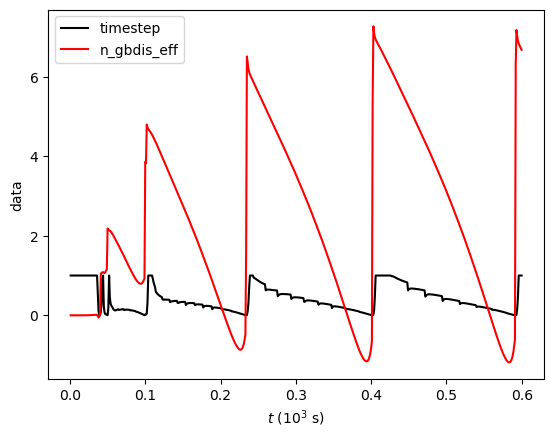

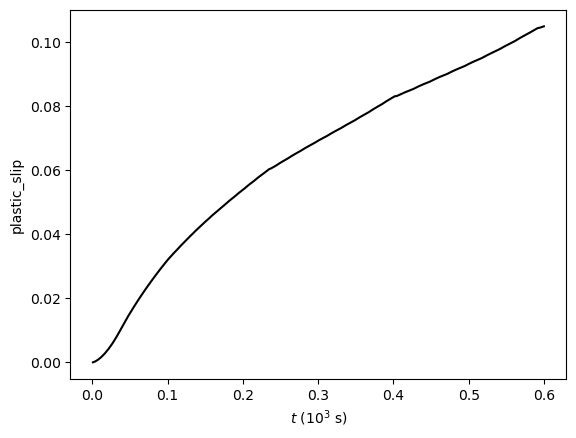

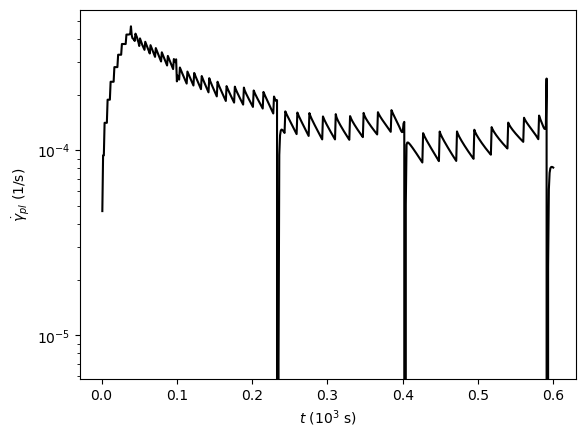

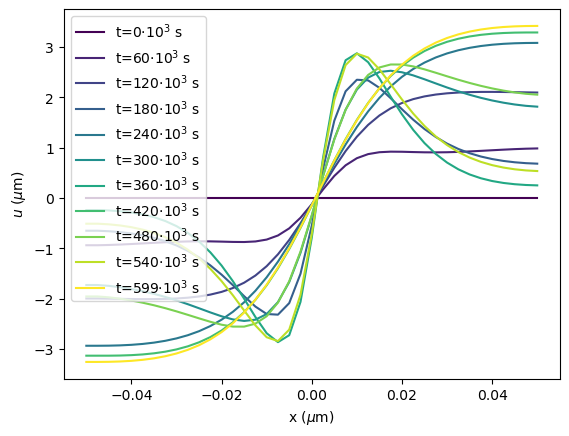

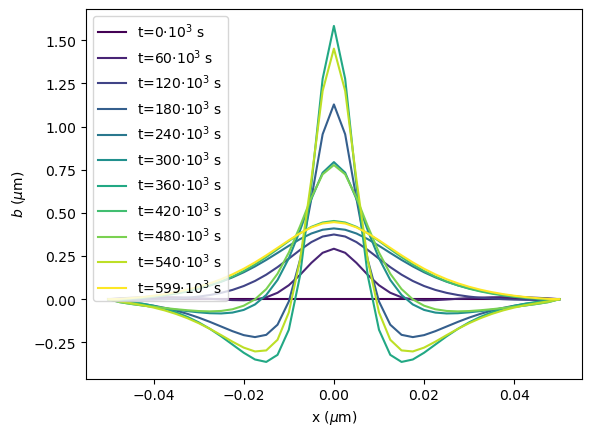

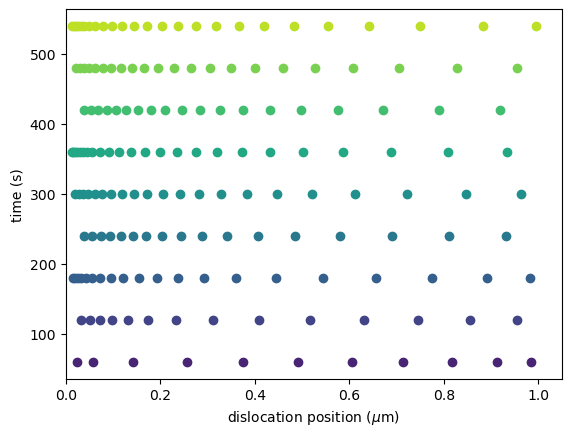

In [2]:
gbdd = dd.GB_dislocations(from_file="../examples/gbdd/pu1_tau150_T900.h5")
gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
gbdd.plot_time_series("plastic_slip")
gbdd.plot_time_series("plast_slip_rate")
gbdd.plot_field('displacement')
gbdd.plot_field('bfield')  # , file="T900_Lgb10_short.pdf")
gbdd.plot_pile_up()
                          

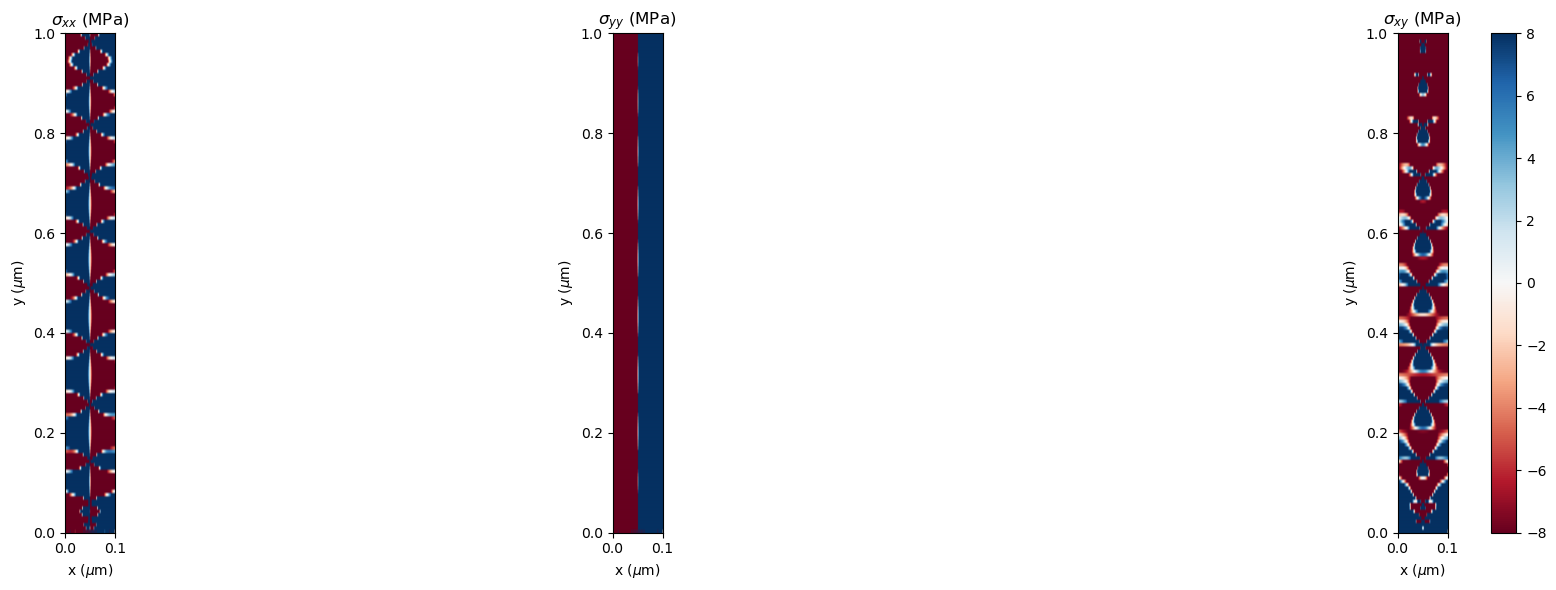

[ 1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.          0.
  0.00529344  0.00841311  0.01052777  0.01175911  0.0120548   0.01132284
  0.00949321  0.00658223  0.00278514 -0.00138619 -0.00490985 -0.00601353
 -0.00194397  0.01109879  0.03754487  0.08104136  0.14147835  0.21059484
  0.26908482  0.29255058  0.26908482  0.21059484  0.14147835  0.08104136
  0.03754487  0.01109879 -0.00194397 -0.00601353 -0.00490985 -0.00138619
  0.00278514  0.00658223  0.00949321  0.01132284  0.0120548   0.01175911
  0.01052777  0.00841311  0.00529344  0.        ]
[0.02370445 0.05700887 0.14225987 0.25684462 0.37491278 0.49135216
 0.60469853 0.71397849 0.81774273 0.91272745 0.984111  ]
[-0.03168826 -0.01758402 -0.03147002 -0.03563838 -0.03610962 -0.03544796
 -0.03424441 -0.03261132 -0.03043429 -0.02733932 -0.01457634]
[-0.00383373 -0.01288312 -0.03092779 -0.03554908 -0.03608428 -0.03543806
 -0.0342397  -0.03260876 -0.03043275 -0.02733831 -

In [35]:
it = 60
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
npu = len(ind)
ngbn = gbdd.Ngbn
ndis = npu + ngbn
xp = np.zeros(ndis)
yp = np.zeros(ndis)
by = np.ones(ndis)
yp[0:npu] = hh[ind]  # positions of pile-up dislocations stored in first section of array, GB is at y=0
xp[0:npu] = np.ones(npu)*gbdd.Dgp*0.5  # x-positions of pile-up dislocations
xp[npu:] = gbdd.gb_node_pos + gbdd.Dgp*0.5
by[npu:] = gbdd.field_data['bfield'][it, :]  #np.zeros(ngbn) #
gbf = gbdd.pu_dis['force'][it, ind]

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, npu, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,
                      bc="fixed")
dsl.by = by
dsl.plot_stress(show_arrows=False)
fpk = dsl.calc_force(tau0=-gbdd.tau0)
print(by)
print(yp[:npu])
print(fpk[1, :])
print(gbf)

In [32]:
yp


array([0.4962996 , 0.61594943, 0.71877397, 0.81226908, 0.89730235,
       0.96994668, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        ])

In [ ]:
N = 100
res = []
for i in range(N):
    xp = np.random.rand(2)*5
    yp = np.random.rand(2)*5
    sp = np.random.rand(1)[0]*np.pi*.5
    df = dd.Dislocations(2, 2, sp, C, gbdd.B,
                          xpos=xp, ypos=yp, LX=5, LY=5,
                          bc="fixed")
    dp = dd.Dislocations(2, 2, sp, C, gbdd.B,
                          xpos=xp, ypos=yp, LX=50000, LY=50000,
                          bc="pbc")
    res.append(df.calc_force(tau0=0) / dp.calc_force(tau0=0) - 1)
    #print(dp.xpos, dp.ypos)
    #print(dp.bx, dp.by)
    #print(res[i])
print(np.max(np.abs(res)))


In [ ]:
mu = 80.0e3          # shear modulus
nu = 0.3             # Poisson ratio
b0 = 0.2e-3          # Burgers vector norm
C = mu*b0/(2*np.pi*(1.-nu))   # Constant for dislocation stress field
f0 = 10.             # initial slip resistance

#define box 
LX = LY = 10.

#define different dislocations in box
dsl10 = dd.Dislocations(1, 0, 0., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl10.plot_stress()             # plot elastic fields

dsl01 = dd.Dislocations(1, 0, 90.*np.pi/180., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl01.plot_stress()             # plot elastic fields

dsl11 = dd.Dislocations(1, 0, 45.*np.pi/180., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl11.plot_stress()             # plot elastic fields